# Vagu Labs — Employee Attendance (Bangalore, Q1 2026): Exploratory Data Analysis

**Dataset:** `employee_attendance_bangalore_q1_2026.csv` (55,374 rows × 22 columns)
**Workflow followed:** *Exploratory Data Analysis — A Standard 23-Step Checklist for Any Dataset*
(Classroom Computer Institute — Data Analytics)

This notebook walks through **all 23 steps** of the checklist, in order, across four phases:

| Phase | Steps | Goal |
|---|---|---|
| Phase 1 — Inspect | 1–8 | Understand the shape, structure, and quality of the raw data |
| Phase 2 — Clean & Prepare | 9–17 | Organize columns, clean values, export a final clean dataset |
| Phase 3 — Analyze | 18–21 | Explore relationships and statistically test them |
| Phase 4 — Report | 22–23 | Define KPIs and charts for the final dashboard |

Each step below has its own markdown explanation followed by the code that performs it. Unlike a
deliberately "messy" practice dataset, this one is a real day-to-day HR export — several checklist
steps will conclude **"no issues found,"** which is itself a valid and useful outcome of running the
checklist.


In [1]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)

RAW_PATH = "/kaggle/input/datasets/satyakidas07/employee-attendance-and-login-logout-data-bangalore/employee_attendance_bangalore_q1_2026.csv"
df = pd.read_csv(RAW_PATH)
df.head()

,attendance_id,employee_id,employee_name,gender,department,designation,employment_type,office_location,date_of_joining,attendance_date,shift_type,attendance_status,work_mode,login_timestamp,logout_timestamp,total_hours_worked,break_duration_mins,net_productive_hours,late_arrival_mins,early_exit_mins,overtime_hours,leave_type
0,ATT0000001,VL1000,Arjun Verma,Male,Engineering,Software Engineer Intern,Intern,Koramangala HQ,2025-06-26,2026-01-02,General (09:30-18:30),Present,Work From Office,2026-01-02 09:42:03,2026-01-02 18:34:12,8.87,86,7.44,12,0,0.00,Not Applicable
1,ATT0000002,VL1001,Rekha Chatterjee,Female,Operations,Operations Manager,Full-Time,Koramangala HQ,2024-02-16,2026-01-02,General (09:30-18:30),Present,Work From Home,2026-01-02 09:09:11,2026-01-02 18:25:11,9.27,67,8.15,0,6,0.00,Not Applicable
2,ATT0000003,VL1002,Tanmay Bhardwaj,Male,Operations,Operations Analyst,Full-Time,Whitefield Tech Park,2020-10-13,2026-01-02,General (09:30-18:30),Present,Work From Home,2026-01-02 09:45:59,2026-01-02 20:17:31,10.53,57,9.58,15,0,0.58,Not Applicable
3,ATT0000004,VL1003,Aditya Bose,Female,Customer Success,Customer Success Executive,Full-Time,Koramangala HQ,2022-01-10,2026-01-02,Late/US Overlap (14:00-23:00),Present,Work From Office,2026-01-02 13:49:26,2026-01-02 22:24:51,8.59,76,7.32,0,36,0.00,Not Applicable
4,ATT0000005,VL1004,Uday Acharya,Male,Human Resources,Talent Acquisition Partner,Full-Time,Electronic City Campus,2024-09-09,2026-01-02,Flexible (10:30-19:30),Present,Work From Office,2026-01-02 10:51:02,2026-01-02 20:33:39,9.71,61,8.69,20,0,0.00,Not Applicable


## Phase 1 — Inspect the Raw Data (Steps 1–8)

Understand the shape, structure, and quality of the raw data.

### Step 1 — Total Number of Rows
Check the row count to understand the dataset's size (`df.shape[0]`).

In [2]:
n_rows = df.shape[0]
print(f"Total rows: {n_rows}")

Total rows: 55374


### Step 2 — Total Number of Columns
Check the column count (`df.shape[1]`).

In [3]:
n_cols = df.shape[1]
print(f"Total columns: {n_cols}")

Total columns: 22


### Step 3 — Understanding of Each Column
Go through every column and note what it represents, its expected values, and how it relates to the
problem.

| Column | Represents | Expected values |
|---|---|---|
| attendance_id | Unique row/record identifier | `ATT#######` |
| employee_id | Unique employee identifier | `VL####` (repeats across many days per employee) |
| employee_name | Employee's name | Free text |
| gender | Employee gender | Male, Female, Prefer Not to Say |
| department | Employee's department | Engineering, Sales, Customer Success, etc. |
| designation | Job title | 48 distinct titles |
| employment_type | Employment category | Full-Time, Contract, Intern, Part-Time |
| office_location | Bangalore office campus | Koramangala HQ, Whitefield Tech Park, HSR Layout Hub, etc. |
| date_of_joining | Date employee joined | Should be on/before `attendance_date` |
| attendance_date | The calendar date of this record | Jan 2 2026 – Mar 31 2026 (Q1 2026) |
| shift_type | Assigned shift window | General, Flexible, Mid, Early, Late/US Overlap |
| attendance_status | Day-level outcome | Present, Half Day, On Leave |
| work_mode | Where the employee worked from | Work From Office, Work From Home, Client Site, Not Applicable (on leave) |
| login_timestamp / logout_timestamp | Clock-in / clock-out time | Null when `attendance_status == On Leave` |
| total_hours_worked | Hours between login and logout | 0 on leave days, otherwise positive |
| break_duration_mins | Minutes spent on breaks | Positive integer |
| net_productive_hours | `total_hours_worked` minus break time (roughly) | Positive float, ≤ `total_hours_worked` |
| late_arrival_mins | Minutes late vs. shift start | 0 if on time |
| early_exit_mins | Minutes left early vs. shift end | 0 if not an early exit |
| overtime_hours | Hours worked beyond shift | 0 if none |
| leave_type | Type of leave taken | "Not Applicable" unless `attendance_status == On Leave` |


In [4]:
info_df = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "sample_value": df.iloc[3]
})
info_df

,dtype,n_unique,sample_value
attendance_id,object,55374,ATT0000004
employee_id,object,980,VL1003
employee_name,object,980,Aditya Bose
gender,object,3,Female
department,object,10,Customer Success
designation,object,48,Customer Success Executive
employment_type,object,4,Full-Time
office_location,object,5,Koramangala HQ
date_of_joining,object,804,2022-01-10
attendance_date,object,57,2026-01-02


### Step 4 — Trim Extra Spaces
Strip leading/trailing whitespace from string columns and column headers — hidden spaces silently
break groupby, filtering, and joins. We first **detect** which columns are affected before fixing
them (the fix, if any is needed, happens formally in Step 16).

In [5]:
print("Header whitespace issues:", [c for c in df.columns if c != c.strip()])

obj_cols = df.select_dtypes(include="object").columns
whitespace_flagged = {}
for col in obj_cols:
    s = df[col].dropna().astype(str)
    whitespace_flagged[col] = int((s.str.strip() != s).sum())

flagged = {k: v for k, v in whitespace_flagged.items() if v > 0}
print(flagged if flagged else "No leading/trailing whitespace found in any string column.")

Header whitespace issues: []
No leading/trailing whitespace found in any string column.


### Step 5 — Remove Duplicate Elements
Identify and drop duplicate rows (`df.duplicated()`, `df.drop_duplicates()`).

In [6]:
n_dupes_full = df.duplicated().sum()
n_dupes_id = df["attendance_id"].duplicated().sum()
print(f"Fully duplicated rows: {n_dupes_full}")
print(f"Duplicated attendance_id values: {n_dupes_id}")

Fully duplicated rows: 0
Duplicated attendance_id values: 0


### Step 6 — Check Memory Size
Check memory usage (`df.memory_usage(deep=True)`) — flags if dtypes need downcasting for efficiency.

In [7]:
mem = df.memory_usage(deep=True)
print(mem)
print(f"\nTotal memory: {mem.sum() / 1024**2:.2f} MB")

Index                       132
attendance_id           3267066
employee_id             3045570
employee_name           3442982
gender                  2980742
department              3312109
designation             3830839
employment_type         3198638
office_location         3651166
date_of_joining         3267066
attendance_date         3267066
shift_type              3904830
attendance_status       3104765
work_mode               3564478
login_timestamp         3670572
logout_timestamp        3670572
total_hours_worked       442992
break_duration_mins      442992
net_productive_hours     442992
late_arrival_mins        442992
early_exit_mins          442992
overtime_hours           442992
leave_type              3483852
dtype: int64

Total memory: 54.66 MB


### Step 7 — Check Data Type of Columns
Verify each column's dtype matches what it should be (e.g., dates not stored as text, numbers not
stored as objects).

In [8]:
df.dtypes

attendance_id            object
employee_id              object
employee_name            object
gender                   object
department               object
designation              object
employment_type          object
office_location          object
date_of_joining          object
attendance_date          object
shift_type               object
attendance_status        object
work_mode                object
login_timestamp          object
logout_timestamp         object
total_hours_worked      float64
break_duration_mins       int64
net_productive_hours    float64
late_arrival_mins         int64
early_exit_mins           int64
overtime_hours          float64
leave_type               object
dtype: object

In [9]:
should_be_datetime = ["date_of_joining", "attendance_date", "login_timestamp", "logout_timestamp"]
print("Currently wrong dtype (datetime expected):")
print(df[should_be_datetime].dtypes)
print("\nNumeric columns already correctly typed:")
print(df.select_dtypes(include="number").dtypes)

Currently wrong dtype (datetime expected):
date_of_joining     object
attendance_date     object
login_timestamp     object
logout_timestamp    object
dtype: object

Numeric columns already correctly typed:
total_hours_worked      float64
break_duration_mins       int64
net_productive_hours    float64
late_arrival_mins         int64
early_exit_mins           int64
overtime_hours          float64
dtype: object


### Step 8 — Check Total Number of Null Values
Count missing values per column (`df.isnull().sum()`) to plan the cleaning strategy.

In [10]:
null_counts = df.isnull().sum().sort_values(ascending=False)
null_pct = (null_counts / len(df) * 100).round(2)
pd.DataFrame({"nulls": null_counts, "pct_missing": null_pct}).loc[null_counts > 0]

,nulls,pct_missing
logout_timestamp,2635,4.76
login_timestamp,2635,4.76


In [11]:
# Are the nulls explained by attendance_status? (login/logout should be null exactly on leave days)
print(pd.crosstab(df["attendance_status"], df["login_timestamp"].isnull()))
print("\n-> Nulls in login/logout_timestamp are fully explained by 'On Leave' status -- not a data")
print("   quality defect, just a structurally-absent value that should stay NaN.")

login_timestamp    False  True 
attendance_status              
Half Day            1186      0
On Leave               0   2635
Present            51553      0

-> Nulls in login/logout_timestamp are fully explained by 'On Leave' status -- not a data
   quality defect, just a structurally-absent value that should stay NaN.


## Phase 2 — Clean & Prepare (Steps 9–17)

Organize columns, clean values, and export a final clean dataset.

### Step 9 — Split Columns: Numerical vs Categorical
Separate columns into numerical and categorical groups — they need different analysis and cleaning
approaches.

In [12]:
numerical_cols = ["total_hours_worked", "break_duration_mins", "net_productive_hours",
                   "late_arrival_mins", "early_exit_mins", "overtime_hours"]
categorical_cols = ["gender", "department", "designation", "employment_type", "office_location",
                     "shift_type", "attendance_status", "work_mode", "leave_type"]
datetime_cols = ["date_of_joining", "attendance_date", "login_timestamp", "logout_timestamp"]
id_cols = ["attendance_id", "employee_id"]

print("Numerical:", numerical_cols)
print("\nCategorical:", categorical_cols)
print("\nDate/Time:", datetime_cols)
print("\nID columns:", id_cols)

Numerical: ['total_hours_worked', 'break_duration_mins', 'net_productive_hours', 'late_arrival_mins', 'early_exit_mins', 'overtime_hours']

Categorical: ['gender', 'department', 'designation', 'employment_type', 'office_location', 'shift_type', 'attendance_status', 'work_mode', 'leave_type']

Date/Time: ['date_of_joining', 'attendance_date', 'login_timestamp', 'logout_timestamp']

ID columns: ['attendance_id', 'employee_id']


### Step 10 — `describe()` of Numerical Columns
Run `df.describe()` to see count, mean, std, min, quartiles, and max for numerical columns.

In [13]:
df[numerical_cols].describe()

,total_hours_worked,break_duration_mins,net_productive_hours,late_arrival_mins,early_exit_mins,overtime_hours
count,55374.000000,55374.000000,55374.000000,55374.000000,55374.000000,55374.000000
mean,8.724951,59.741955,7.729238,9.858471,20.099198,0.150049
std,2.413434,23.878616,2.223308,19.465159,49.630750,0.367258
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.470000,47.000000,7.370000,0.000000,0.000000,0.000000
50%,9.280000,62.000000,8.210000,0.000000,0.000000,0.000000
75%,10.000000,76.000000,8.960000,14.000000,16.000000,0.000000
max,13.660000,135.000000,12.860000,218.000000,391.000000,3.860000


### Step 11 — Write a Summary of the Dataset

**Summary:** This dataset is a daily attendance log for Vagu Labs' Bangalore workforce across Q1
2026 (Jan 2 – Mar 31). Each of the 55,374 rows is one employee-day record, covering 980 unique
employees across 10 departments and 5 Bangalore office locations. It captures shift assignment,
attendance outcome (Present / Half Day / On Leave), work mode (office / home / client site),
clock-in/out timestamps, hours worked, breaks, punctuality (late arrival / early exit), overtime,
and leave type.

**Source:** HR attendance export (`employee_attendance_bangalore_q1_2026.csv`), treated as a
day-to-day operational dataset rather than a teaching-messy one.

**Size:** 55,374 rows × 22 columns, ~980 employees averaging ~57 records each (working days in Q1
2026 minus weekends).

**General quality:** Notably clean — zero duplicate rows, zero whitespace issues, zero inconsistent
category labels, and employee-level attributes (name, gender, department, designation, etc.) are
fully consistent across every row for the same `employee_id`. The only missing values
(`login_timestamp` / `logout_timestamp`, 2,635 rows each) are structurally correct — they occur
exactly on "On Leave" days, not as a data-entry gap. The main cleaning work needed is **type
correction** (dates/timestamps stored as text) rather than fixing broken values.

In [14]:
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(f"Unique employees: {df['employee_id'].nunique()}")
print(f"Departments: {sorted(df['department'].unique())}")
attendance_date_notnull = df['attendance_date'].dropna()
print(f"Attendance date range: {attendance_date_notnull.min()} .. {attendance_date_notnull.max()}")
print(f"\nAttendance status breakdown:\n{df['attendance_status'].value_counts()}")

Rows: 55,374  |  Columns: 22
Unique employees: 980
Departments: ['Customer Success', 'Data Science', 'Design', 'Engineering', 'Finance', 'Human Resources', 'Marketing', 'Operations', 'Product Management', 'Sales']
Attendance date range: 2026-01-02 .. 2026-03-31

Attendance status breakdown:
attendance_status
Present     51553
On Leave     2635
Half Day     1186
Name: count, dtype: int64


### Step 12 — Write the Problem Statement

**Problem Statement:** *What are the attendance, punctuality, and productivity patterns of Vagu
Labs' Bangalore workforce in Q1 2026, and how do they vary by department, work mode, shift type, and
employment type? Specifically, what is associated with late arrivals, early exits, and leave-taking
— and is remote work adoption uneven across departments?*

This drives every scoping decision from here on — which columns are required, which derived metrics
matter, and which relationships we test statistically.

### Step 13 — Mention the Columns That Are Required
Columns needed to answer the problem statement above:

- **Identifiers (for grouping):** `employee_id`
- **Who:** `gender`, `department`, `designation`, `employment_type`, `office_location`, `date_of_joining`
- **When:** `attendance_date`, `shift_type`
- **Outcome:** `attendance_status`, `work_mode`, `login_timestamp`, `logout_timestamp`, `leave_type`
- **Effort/Punctuality:** `total_hours_worked`, `break_duration_mins`, `net_productive_hours`, `late_arrival_mins`, `early_exit_mins`, `overtime_hours`

### Step 14 — Drop the Columns That Are Not Required
Not needed to answer the problem statement:

- `employee_name` — PII, not needed for aggregate/departmental analysis (`employee_id` retained for grouping)
- `attendance_id` — pure row identifier with no analytic value once the DataFrame index exists

In [15]:
cols_to_drop = ["employee_name", "attendance_id"]
df = df.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} column(s). Remaining: {df.shape[1]}")
df.columns.tolist()

Dropped 2 column(s). Remaining: 20


['employee_id',
 'gender',
 'department',
 'designation',
 'employment_type',
 'office_location',
 'date_of_joining',
 'attendance_date',
 'shift_type',
 'attendance_status',
 'work_mode',
 'login_timestamp',
 'logout_timestamp',
 'total_hours_worked',
 'break_duration_mins',
 'net_productive_hours',
 'late_arrival_mins',
 'early_exit_mins',
 'overtime_hours',
 'leave_type']

### Step 15 — Add Derived Columns If Required
Useful columns not present in the raw data, created from existing ones:

- `attendance_month`, `attendance_weekday` — extracted from `attendance_date` once parsed
- `tenure_days` — `attendance_date` minus `date_of_joining`
- `is_late` — `late_arrival_mins > 0`
- `is_early_exit` — `early_exit_mins > 0`
- `productivity_ratio` — `net_productive_hours / total_hours_worked` (only meaningful on worked days)

(Computed together with Step 16 below, since they depend on the parsed/typed versions of their
source columns.)

### Step 16 — Perform Cleaning Operations on Each Column
Applying the right cleaning method based on each column's type and role: text/categorical
standardization, numerical outlier/skew checks, date/time parsing, ID validation, and cross-column
consistency checks.

**16a — Text / Categorical columns:** strip whitespace and check for inconsistent labels. As
found in Step 4, this dataset has none — the step is still run (rather than skipped) so the
notebook's cleaning logic is complete and reusable on a messier extract of the same data.

In [16]:
df.columns = df.columns.str.strip()
str_cols = df.select_dtypes(include="object").columns
for c in str_cols:
    df[c] = df[c].astype(str).str.strip()
    df.loc[df[c].isin(["", "nan", "None"]), c] = np.nan

for c in ["gender", "department", "employment_type", "work_mode", "attendance_status", "leave_type"]:
    print(f"{c}: {sorted(df[c].dropna().unique())}")

gender: ['Female', 'Male', 'Prefer Not to Say']
department: ['Customer Success', 'Data Science', 'Design', 'Engineering', 'Finance', 'Human Resources', 'Marketing', 'Operations', 'Product Management', 'Sales']
employment_type: ['Contract', 'Full-Time', 'Intern', 'Part-Time']
work_mode: ['Client Site', 'Not Applicable', 'Work From Home', 'Work From Office']
attendance_status: ['Half Day', 'On Leave', 'Present']
leave_type: ['Bereavement Leave', 'Casual Leave', 'Earned Leave', 'Loss of Pay', 'Marriage Leave', 'Not Applicable', 'Parental Leave', 'Sick Leave', 'Work From Home Comp-Off']


**16b — Numerical columns:** outlier detection (IQR method) and skewness/kurtosis checks.

In [17]:
# Outlier detection on late_arrival_mins via IQR method
q1, q3 = df["late_arrival_mins"].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = df[(df["late_arrival_mins"] < lower) | (df["late_arrival_mins"] > upper)]
print(f"late_arrival_mins IQR bounds: [{max(lower,0):.0f}, {upper:.0f}]  |  Outliers flagged: {len(outliers)}")
print("These represent genuinely very-late arrivals, not data-entry errors -> kept as-is for analysis.")

late_arrival_mins IQR bounds: [0, 35]  |  Outliers flagged: 2899
These represent genuinely very-late arrivals, not data-entry errors -> kept as-is for analysis.


In [18]:
for c in numerical_cols:
    print(f"{c:22s} skew={df[c].skew():+.2f}   kurtosis={df[c].kurt():+.2f}")
print("\nlate_arrival_mins, early_exit_mins, and overtime_hours are strongly right-skewed, as")
print("expected: most days have 0 minutes late / 0 early exit / 0 overtime, with a long tail.")

total_hours_worked     skew=-2.38   kurtosis=+5.81
break_duration_mins    skew=-0.56   kurtosis=+0.35
net_productive_hours   skew=-2.12   kurtosis=+4.77
late_arrival_mins      skew=+4.20   kurtosis=+22.95
early_exit_mins        skew=+3.78   kurtosis=+16.00
overtime_hours         skew=+3.09   kurtosis=+10.85

late_arrival_mins, early_exit_mins, and overtime_hours are strongly right-skewed, as
expected: most days have 0 minutes late / 0 early exit / 0 overtime, with a long tail.


**16c — Date / Time columns:** parse `date_of_joining`, `attendance_date`, `login_timestamp`,
`logout_timestamp` into proper datetime types, then extract derived parts.

In [19]:
df["date_of_joining"] = pd.to_datetime(df["date_of_joining"], errors="coerce")
df["attendance_date"] = pd.to_datetime(df["attendance_date"], errors="coerce")
df["login_timestamp"] = pd.to_datetime(df["login_timestamp"], errors="coerce")
df["logout_timestamp"] = pd.to_datetime(df["logout_timestamp"], errors="coerce")

print("Unparseable dates:")
print(df[["date_of_joining", "attendance_date", "login_timestamp", "logout_timestamp"]].isna().sum())

df["attendance_month"] = df["attendance_date"].dt.month
df["attendance_weekday"] = df["attendance_date"].dt.day_name()
df["tenure_days"] = (df["attendance_date"] - df["date_of_joining"]).dt.days
df[["attendance_date", "attendance_month", "attendance_weekday", "tenure_days"]].head()

Unparseable dates:
date_of_joining        0
attendance_date        0
login_timestamp     2635
logout_timestamp    2635
dtype: int64


,attendance_date,attendance_month,attendance_weekday,tenure_days
0,2026-01-02,1,Friday,190
1,2026-01-02,1,Friday,686
2,2026-01-02,1,Friday,1907
3,2026-01-02,1,Friday,1453
4,2026-01-02,1,Friday,480


**16d — Derived boolean/ratio columns (Step 15), now that source columns are cleaned/typed.**

In [20]:
df["is_late"] = df["late_arrival_mins"] > 0
df["is_early_exit"] = df["early_exit_mins"] > 0
df["productivity_ratio"] = np.where(
    df["total_hours_worked"] > 0,
    (df["net_productive_hours"] / df["total_hours_worked"]).round(3),
    np.nan
)
df[["is_late", "is_early_exit", "productivity_ratio"]].head()

,is_late,is_early_exit,productivity_ratio
0,True,False,0.839
1,False,True,0.879
2,True,False,0.910
3,False,True,0.852
4,True,False,0.895


**16e — ID / unique-key columns:** validate format consistency.

In [21]:
print("employee_id format check (all match VL####):",
      df["employee_id"].str.match(r"^VL\d{4}$").all())
print("Unique employees:", df["employee_id"].nunique())

employee_id format check (all match VL####): True
Unique employees: 980


**16f — Cross-column & general checks:** logical consistency (`attendance_date` should not
precede `date_of_joining`; `login_timestamp` should be null exactly when `attendance_status` is "On
Leave"), referential checks (each `employee_id` should map to exactly one `department`/`gender`/
etc.), and reset the index.

In [22]:
# Logical check: attendance_date should not be before date_of_joining
bad_dates = df[df["attendance_date"] < df["date_of_joining"]]
print(f"Rows where attendance_date precedes date_of_joining: {len(bad_dates)}")

# Referential check: employee attributes should be constant per employee_id
attr_cols = ["gender", "department", "designation", "employment_type", "office_location", "date_of_joining"]
inconsistent = (df.groupby("employee_id")[attr_cols].nunique() > 1).any(axis=1)
print(f"Employees with inconsistent attributes across rows: {inconsistent.sum()}")

# Logical check: login_timestamp null <=> On Leave
mismatch = df[(df["login_timestamp"].isna()) != (df["attendance_status"] == "On Leave")]
print(f"Rows where login-null doesn't match On-Leave status: {len(mismatch)}")

df = df.reset_index(drop=True)
print(f"\nFinal cleaned shape: {df.shape}")

Rows where attendance_date precedes date_of_joining: 0
Employees with inconsistent attributes across rows: 0
Rows where login-null doesn't match On-Leave status: 0

Final cleaned shape: (55374, 26)


### Step 17 — Convert Into Final `cleaned.csv` File
Export the cleaned, prepared dataset as a single `cleaned.csv` to use as the base for all further
analysis.

In [23]:
CLEANED_PATH = "employee_attendance_bangalore_q1_2026_cleaned.csv"
df.to_csv(CLEANED_PATH, index=False)
print(f"Saved cleaned dataset -> {CLEANED_PATH}  |  shape={df.shape}")

Saved cleaned dataset -> employee_attendance_bangalore_q1_2026_cleaned.csv  |  shape=(55374, 26)


## Phase 3 — Analyze (Steps 18–21)

Explore relationships and statistically test them.

### Step 18 — Univariate Analysis
**Numerical:** histogram, box plot, summary stats (mean, median, mode, std, skew, kurtosis).
**Categorical:** `value_counts()`, bar chart, pie chart.

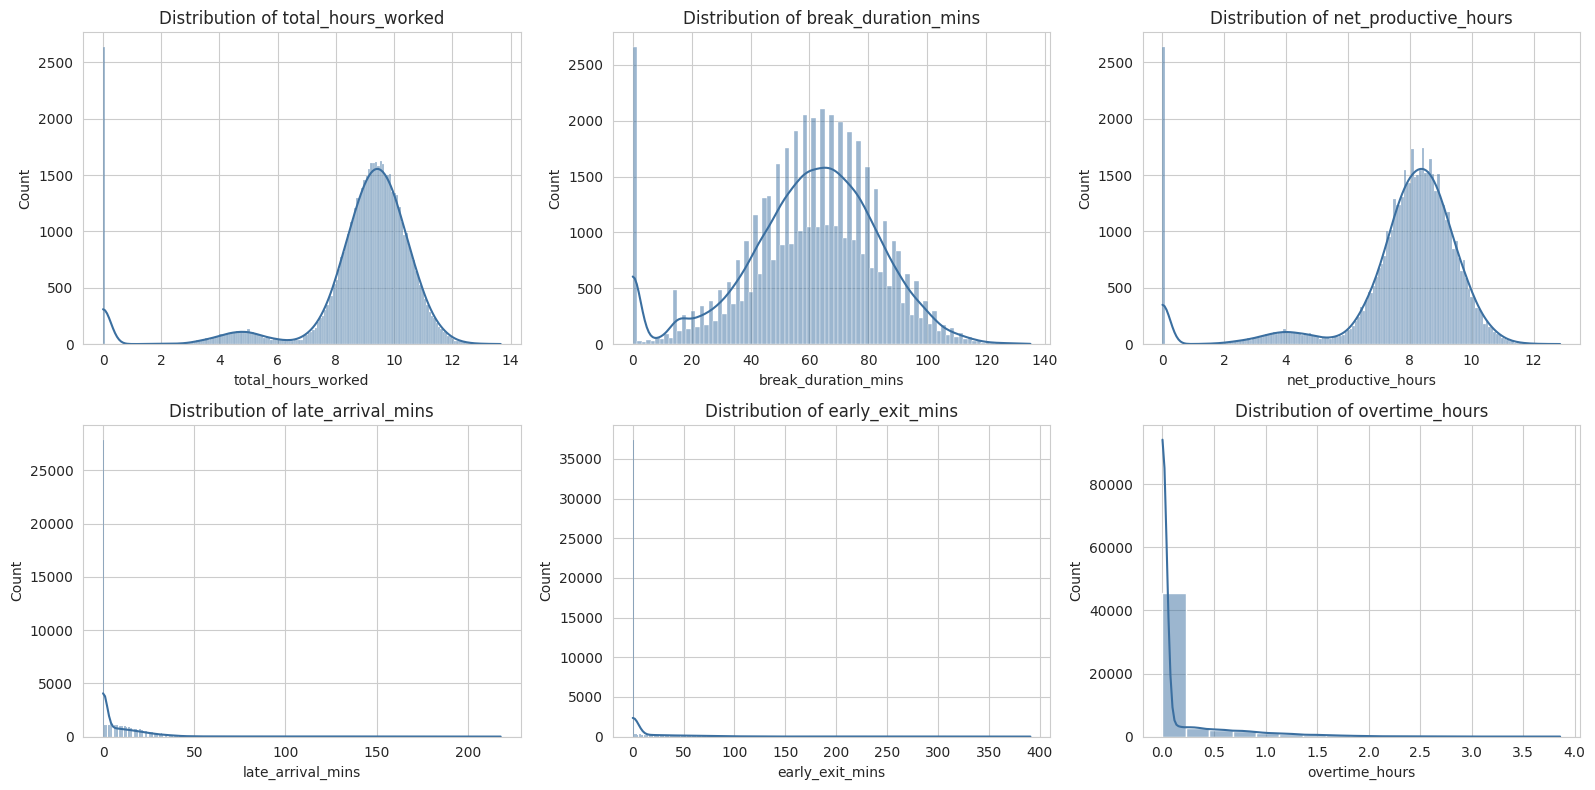

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.flat, numerical_cols):
    sns.histplot(df[c].dropna(), kde=True, ax=ax, color="#3b6fa0")
    ax.set_title(f"Distribution of {c}")
plt.tight_layout()
plt.show()

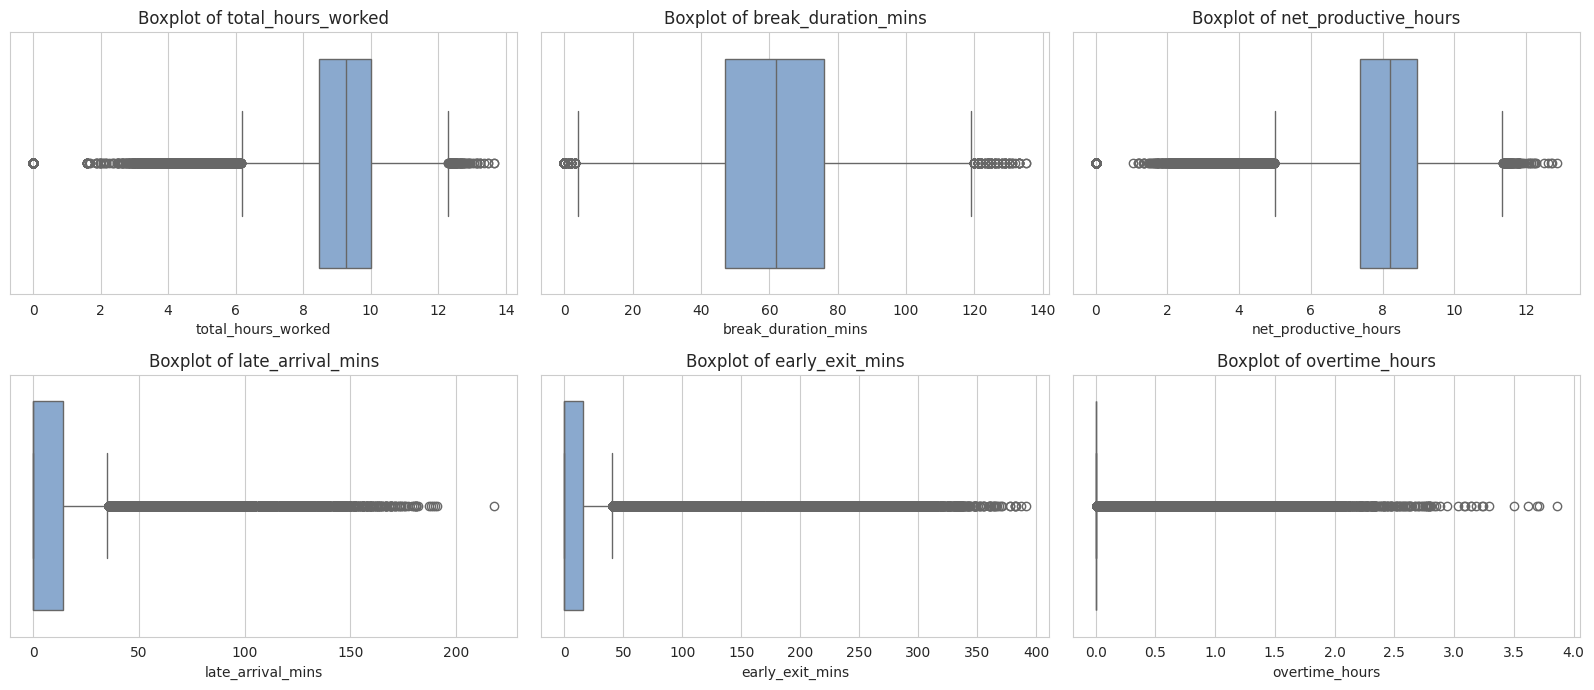

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, c in zip(axes.flat, numerical_cols):
    sns.boxplot(x=df[c], ax=ax, color="#7fa8d9")
    ax.set_title(f"Boxplot of {c}")
plt.tight_layout()
plt.show()

In [26]:
summary_stats = df[numerical_cols].agg(["mean", "median", "std",
                                          lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan,
                                          "skew", "kurt"])
summary_stats.index = ["mean", "median", "std", "mode", "skew", "kurtosis"]
summary_stats

,total_hours_worked,break_duration_mins,net_productive_hours,late_arrival_mins,early_exit_mins,overtime_hours
mean,8.724951,59.741955,7.729238,9.858471,20.099198,0.150049
median,9.280000,62.000000,8.210000,0.000000,0.000000,0.000000
std,2.413434,23.878616,2.223308,19.465159,49.630750,0.367258
mode,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
skew,-2.375093,-0.564780,-2.117598,4.199678,3.781683,3.091640
kurtosis,5.810435,0.354510,4.766283,22.954390,16.000083,10.853740


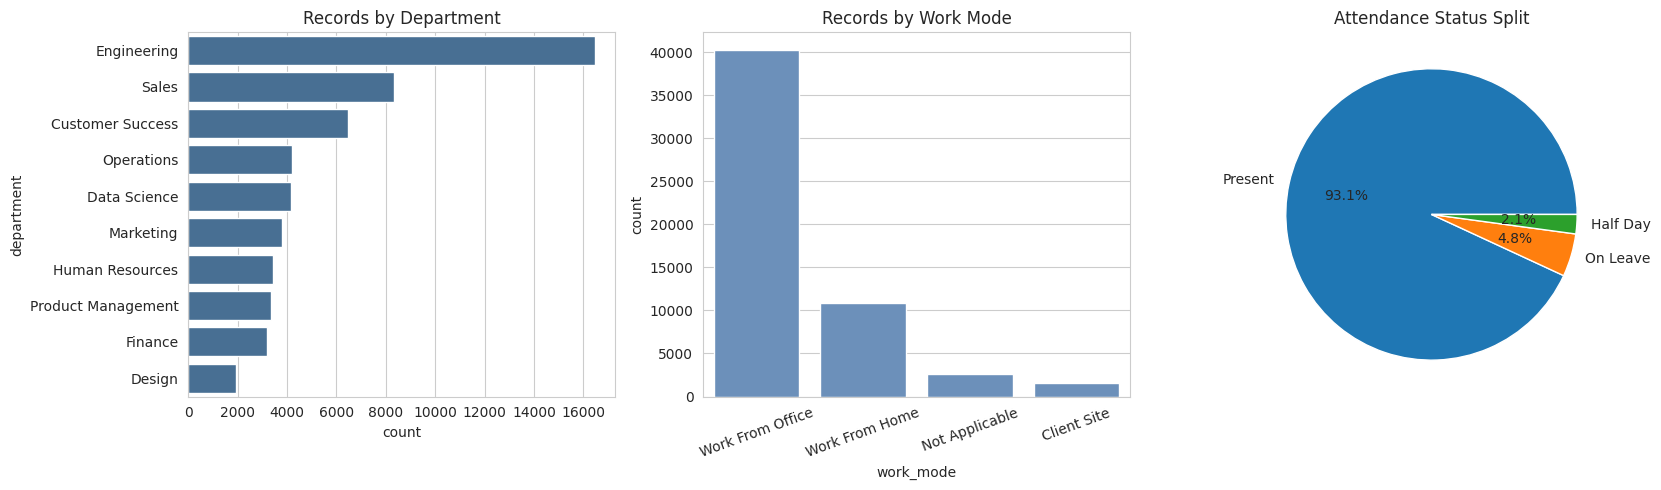

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.countplot(data=df, y="department", order=df["department"].value_counts().index, ax=axes[0], color="#3b6fa0")
axes[0].set_title("Records by Department")

sns.countplot(data=df, x="work_mode", order=df["work_mode"].value_counts().index, ax=axes[1], color="#5f8fc7")
axes[1].set_title("Records by Work Mode"); axes[1].tick_params(axis="x", rotation=20)

df["attendance_status"].value_counts().plot.pie(autopct="%1.1f%%", ax=axes[2], ylabel="")
axes[2].set_title("Attendance Status Split")
plt.tight_layout()
plt.show()

### Step 19 — Bivariate Analysis
**Numerical vs Numerical:** scatter plot + correlation coefficient.
**Numerical vs Categorical:** box plot / bar plot of mean by category.
**Categorical vs Categorical:** cross-tabulation, stacked bar chart.

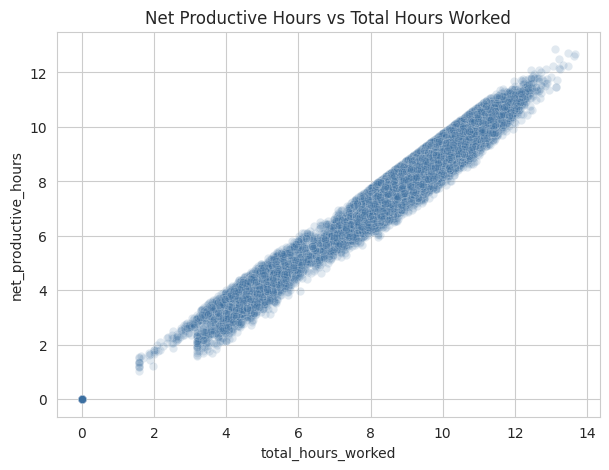

Pearson r = 0.973  (p = 0.00e+00)


In [28]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x="total_hours_worked", y="net_productive_hours", alpha=0.15, ax=ax, color="#3b6fa0")
ax.set_title("Net Productive Hours vs Total Hours Worked")
plt.show()

worked = df[df["total_hours_worked"] > 0]
pearson_r, pearson_p = stats.pearsonr(worked["total_hours_worked"], worked["net_productive_hours"])
print(f"Pearson r = {pearson_r:.3f}  (p = {pearson_p:.2e})")

/tmp/ipykernel_16/95699219.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y="department", x="late_arrival_mins", ax=ax, palette="Blues")


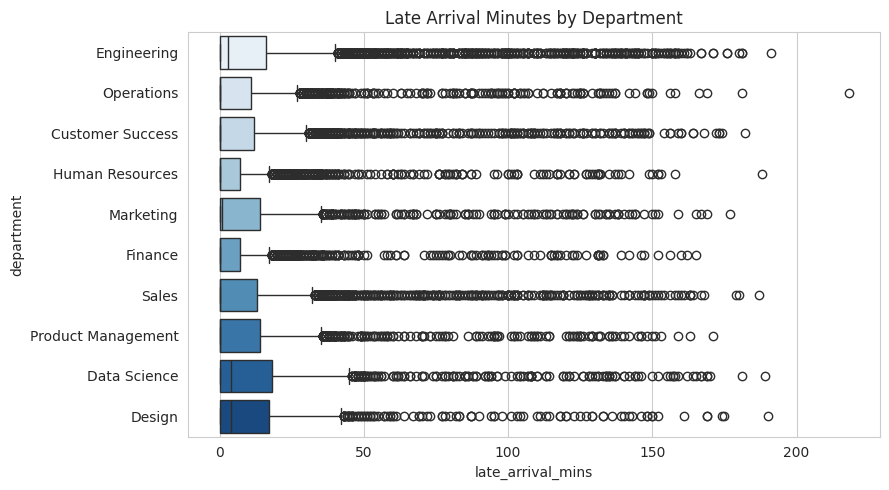

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, y="department", x="late_arrival_mins", ax=ax, palette="Blues")
ax.set_title("Late Arrival Minutes by Department")
plt.tight_layout()
plt.show()

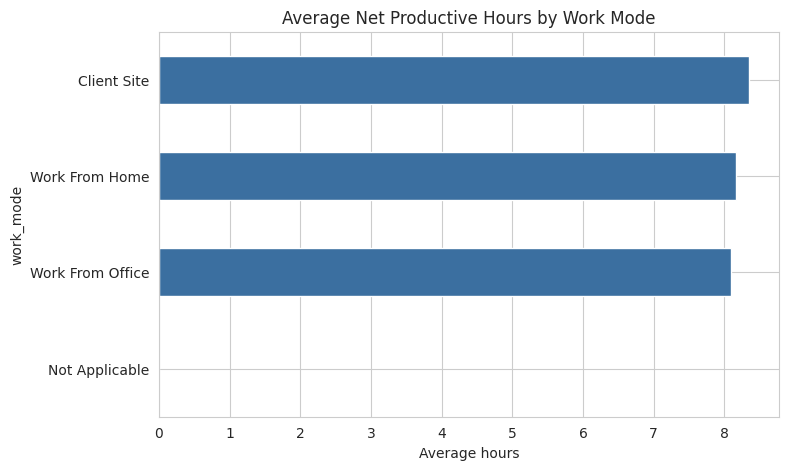

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
df.groupby("work_mode")["net_productive_hours"].mean().sort_values().plot.barh(ax=ax, color="#3b6fa0")
ax.set_title("Average Net Productive Hours by Work Mode")
ax.set_xlabel("Average hours")
plt.show()

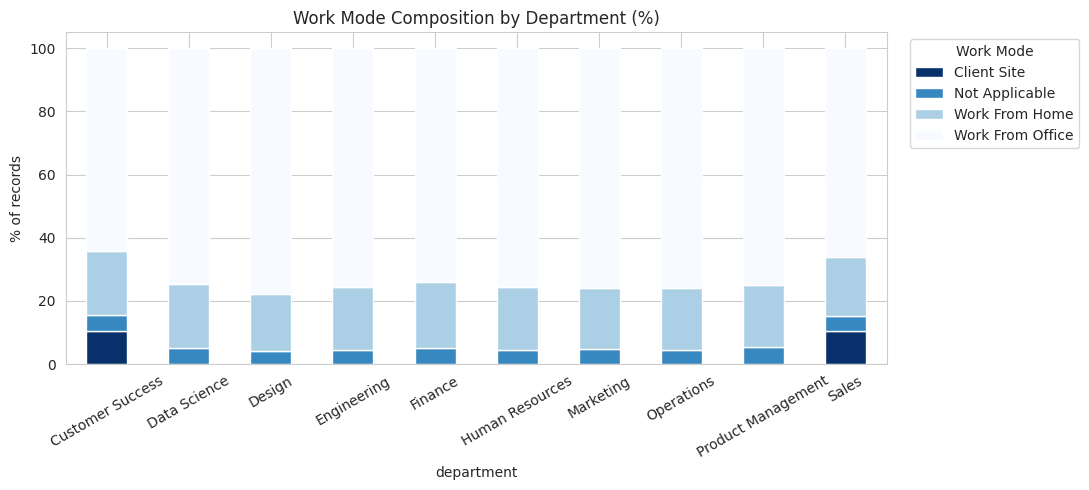

work_mode,Client Site,Not Applicable,Work From Home,Work From Office
department,,,,
Customer Success,10.5,5.0,20.3,64.3
Data Science,0.0,5.2,20.3,74.5
Design,0.0,4.1,18.0,77.9
Engineering,0.0,4.6,19.7,75.7
Finance,0.0,5.0,21.1,73.9
Human Resources,0.0,4.4,20.2,75.5
Marketing,0.0,4.7,19.4,75.9
Operations,0.0,4.6,19.3,76.0
Product Management,0.0,5.3,19.8,74.9


In [31]:
ct = pd.crosstab(df["department"], df["work_mode"], normalize="index") * 100
ct.plot(kind="bar", stacked=True, figsize=(11, 5), colormap="Blues_r")
plt.title("Work Mode Composition by Department (%)")
plt.ylabel("% of records")
plt.xticks(rotation=30)
plt.legend(title="Work Mode", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
ct.round(1)

### Step 20 — Multivariate Analysis
Pair plot across numerical columns, correlation heatmap, grouped box plots with a categorical `hue`,
and a facet grid split by department.

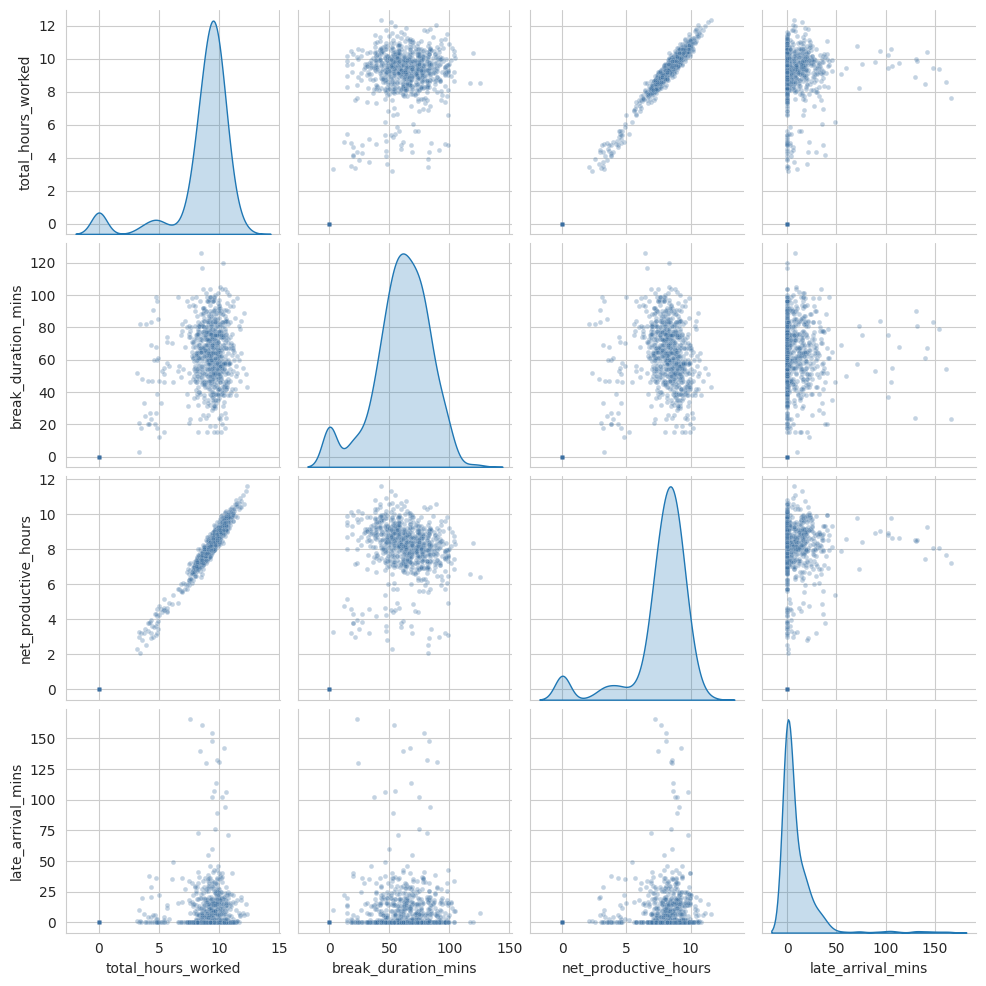

In [32]:
sample_df = df.sample(min(800, len(df)), random_state=42)  # sample for a readable pairplot
sns.pairplot(sample_df[["total_hours_worked", "break_duration_mins", "net_productive_hours",
                         "late_arrival_mins"]].dropna(),
             diag_kind="kde", plot_kws={"alpha": 0.3, "s": 12, "color": "#3b6fa0"})
plt.show()

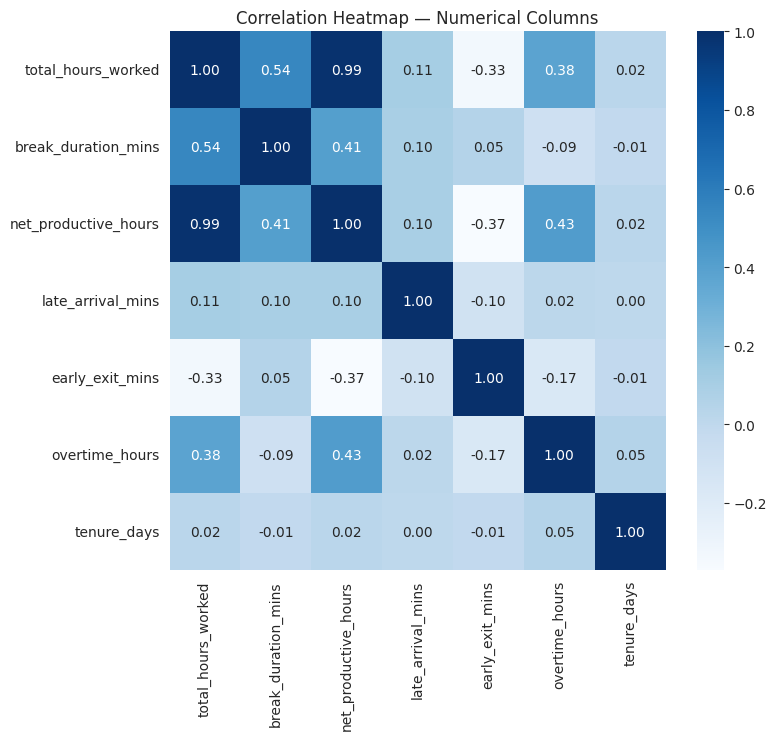

In [33]:
corr = df[numerical_cols + ["tenure_days"]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", ax=ax)
ax.set_title("Correlation Heatmap — Numerical Columns")
plt.show()

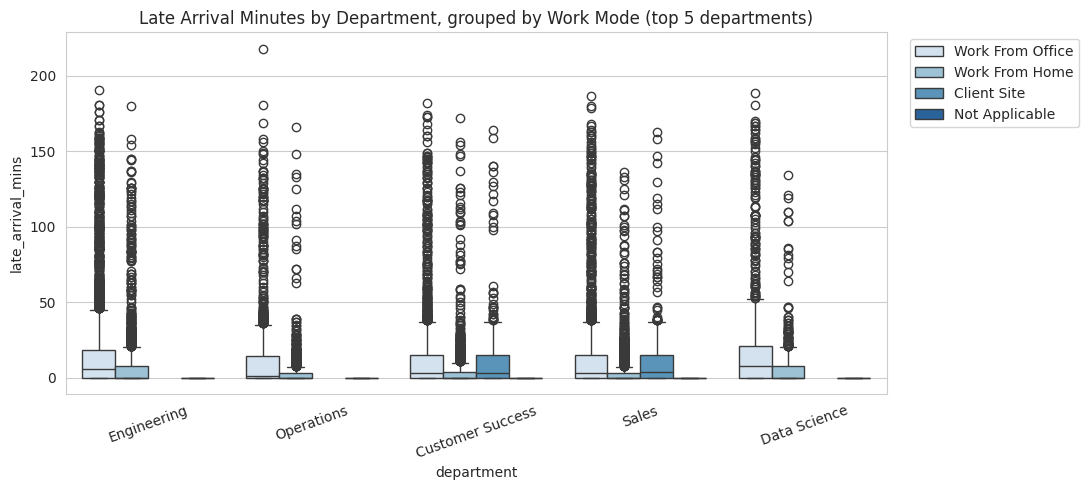

In [34]:
top_depts = df["department"].value_counts().head(5).index
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df[df["department"].isin(top_depts)], x="department", y="late_arrival_mins",
            hue="work_mode", ax=ax, palette="Blues")
ax.set_title("Late Arrival Minutes by Department, grouped by Work Mode (top 5 departments)")
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

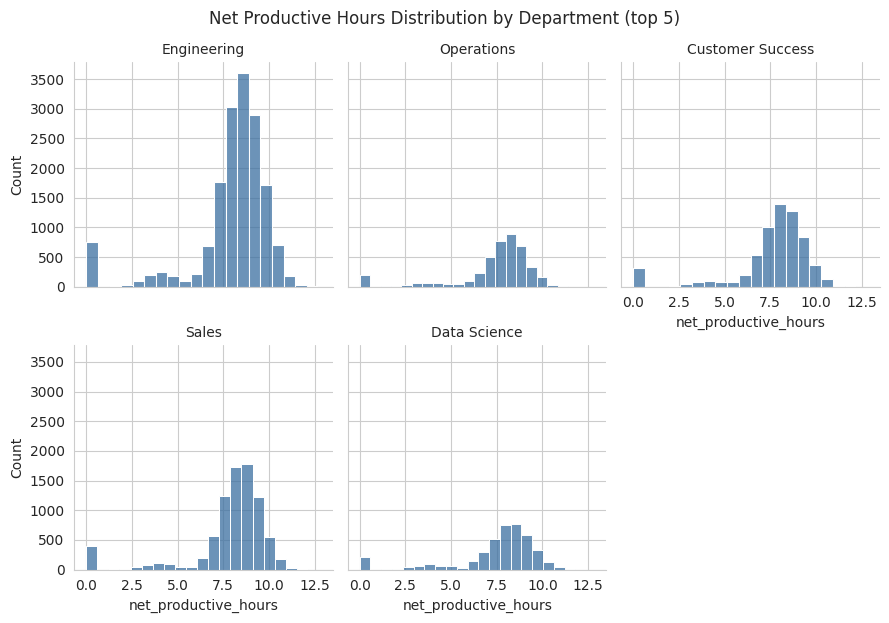

In [35]:
g = sns.FacetGrid(df[df["department"].isin(top_depts)], col="department", col_wrap=3, height=3)
g.map_dataframe(sns.histplot, x="net_productive_hours", color="#3b6fa0", bins=20)
g.set_titles("{col_name}")
g.fig.suptitle("Net Productive Hours Distribution by Department (top 5)", y=1.03)
plt.show()

### Step 21 — Hypothesis Testing
State H₀ (no effect/difference) and H₁ (there is one), then choose the test based on variable types,
checking normality (Shapiro-Wilk, on a sample since N is large) and equal variance (Levene's test)
first.

**21a — Numerical vs Numerical:** Pearson correlation test between `total_hours_worked` and
`net_productive_hours`.

- H₀: There is no linear correlation between hours worked and net productive hours.
- H₁: There is a linear correlation between hours worked and net productive hours.

In [36]:
worked = df[df["total_hours_worked"] > 0]
r, p = stats.pearsonr(worked["total_hours_worked"], worked["net_productive_hours"])
print(f"Pearson r = {r:.3f}, p-value = {p:.2e}")
print("Reject H0 -> significant correlation" if p < 0.05 else "Fail to reject H0")

Pearson r = 0.973, p-value = 0.00e+00
Reject H0 -> significant correlation


**21b — Numerical vs Categorical (2 groups):** t-test comparing `late_arrival_mins` between
Work From Home and Work From Office records.

- H₀: Mean late-arrival minutes is the same for WFH and WFO.
- H₁: Mean late-arrival minutes differs between the two groups.

In [37]:
wfh = df.loc[df["work_mode"] == "Work From Home", "late_arrival_mins"].dropna()
wfo = df.loc[df["work_mode"] == "Work From Office", "late_arrival_mins"].dropna()

shapiro_wfh = stats.shapiro(wfh.sample(min(500, len(wfh)), random_state=1))
levene_stat, levene_p = stats.levene(wfh, wfo)
print(f"Shapiro-Wilk (WFH sample) p = {shapiro_wfh.pvalue:.4f}")
print(f"Levene's test p = {levene_p:.4f}")

t_stat, t_p = stats.ttest_ind(wfh, wfo, equal_var=(levene_p > 0.05))
print(f"\nt-statistic = {t_stat:.3f}, p-value = {t_p:.4f}")
print(f"WFH mean late minutes = {wfh.mean():.2f} | WFO mean late minutes = {wfo.mean():.2f}")
print("Reject H0 -> late-arrival minutes differs by work mode" if t_p < 0.05 else "Fail to reject H0")

Shapiro-Wilk (WFH sample) p = 0.0000
Levene's test p = 0.0000

t-statistic = -28.254, p-value = 0.0000
WFH mean late minutes = 6.07 | WFO mean late minutes = 11.50
Reject H0 -> late-arrival minutes differs by work mode


**21c — Numerical vs Categorical (3+ groups):** one-way ANOVA comparing `net_productive_hours`
across `department`.

- H₀: Mean net productive hours is the same across all departments.
- H₁: At least one department has different mean net productive hours.

In [38]:
groups = [g["net_productive_hours"].dropna().values for _, g in df.groupby("department")]
levene_stat, levene_p = stats.levene(*groups)
f_stat, anova_p = stats.f_oneway(*groups)

print(f"Levene's test p = {levene_p:.4f}")
print(f"ANOVA F = {f_stat:.2f}, p-value = {anova_p:.2e}")
print("Reject H0 -> productive hours differ by department" if anova_p < 0.05 else "Fail to reject H0")

df.groupby("department")["net_productive_hours"].mean().round(2).sort_values(ascending=False)

Levene's test p = 0.0000
ANOVA F = 41.46, p-value = 1.35e-74
Reject H0 -> productive hours differ by department


department
Engineering           7.94
Sales                 7.88
Design                7.73
Product Management    7.69
Human Resources       7.63
Marketing             7.62
Customer Success      7.60
Finance               7.50
Data Science          7.49
Operations            7.45
Name: net_productive_hours, dtype: float64

**21d — Categorical vs Categorical:** Chi-square test of independence between `department` and
`work_mode` (restricted to working days, since "Not Applicable" work mode is definitionally tied to
"On Leave" status).

- H₀: `department` and `work_mode` are independent.
- H₁: `department` and `work_mode` are associated (remote-work adoption differs by department).

In [39]:
working_days = df[df["attendance_status"] != "On Leave"]
contingency = pd.crosstab(working_days["department"], working_days["work_mode"])
chi2, chi_p, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square = {chi2:.2f}, dof = {dof}, p-value = {chi_p:.4f}")
print("Reject H0 -> department and work_mode are associated" if chi_p < 0.05 else "Fail to reject H0")
contingency

Chi-square = 4423.64, dof = 18, p-value = 0.0000
Reject H0 -> department and work_mode are associated


work_mode,Client Site,Work From Home,Work From Office
department,,,
Customer Success,678,1316,4166
Data Science,0,846,3103
Design,0,351,1516
Engineering,0,3240,12455
Finance,0,672,2359
Human Resources,0,694,2599
Marketing,0,734,2873
Operations,0,816,3207
Product Management,0,666,2518


## Phase 4 — Report (Steps 22–23)

Define KPIs and charts for the final dashboard.

### Step 22 — Identify Key Metrics / KPIs for Dashboard
Chosen based on the problem statement (Step 12) and the HR/Operations domain — each is measurable,
tied to the problem statement, and drives an actual decision:

- **Attendance Rate %** (Present + Half Day ÷ total records)
- **Leave (Absenteeism) Rate %**
- **On-Time Arrival Rate %** (`late_arrival_mins == 0`)
- **Average Late Arrival Minutes** and **Average Early Exit Minutes**
- **Average Net Productive Hours**
- **WFH Adoption %**
- **Total Overtime Hours**
- **Half-Day Rate %**

In [40]:
kpis = {
    "Total Attendance Records": len(df),
    "Unique Employees": df["employee_id"].nunique(),
    "Attendance Rate %": df["attendance_status"].isin(["Present", "Half Day"]).mean() * 100,
    "Leave Rate %": (df["attendance_status"] == "On Leave").mean() * 100,
    "Half-Day Rate %": (df["attendance_status"] == "Half Day").mean() * 100,
    "On-Time Arrival Rate %": (df["late_arrival_mins"] == 0).mean() * 100,
    "Average Late Arrival (mins)": df["late_arrival_mins"].mean(),
    "Average Early Exit (mins)": df["early_exit_mins"].mean(),
    "Average Net Productive Hours": df.loc[df["total_hours_worked"] > 0, "net_productive_hours"].mean(),
    "WFH Adoption %": (df["work_mode"] == "Work From Home").mean() * 100,
    "Total Overtime Hours": df["overtime_hours"].sum(),
}
kpi_df = pd.DataFrame.from_dict(kpis, orient="index", columns=["value"]).round(2)
kpi_df

,value
Total Attendance Records,55374.00
Unique Employees,980.00
Attendance Rate %,95.24
Leave Rate %,4.76
Half-Day Rate %,2.14
On-Time Arrival Rate %,50.37
Average Late Arrival (mins),9.86
Average Early Exit (mins),20.10
Average Net Productive Hours,8.12
WFH Adoption %,19.70


In [41]:
df.groupby("department")["net_productive_hours"].mean().sort_values(ascending=False).round(2)

department
Engineering           7.94
Sales                 7.88
Design                7.73
Product Management    7.69
Human Resources       7.63
Marketing             7.62
Customer Success      7.60
Finance               7.50
Data Science          7.49
Operations            7.45
Name: net_productive_hours, dtype: float64

### Step 23 — Identify Important Charts for Dashboard
Chart types recommended by the checklist, applied to this dataset:

- **KPI cards** — the headline metrics from Step 22
- **Trend line chart** — daily attendance rate over Q1 2026
- **Bar chart** — average net productive hours by department
- **Pie/donut chart** — attendance status split (already shown in Step 18)
- **Heatmap** — correlation matrix (already shown in Step 20) / weekday × department attendance density
- **Geo map** — not applicable at metro-city grain (single city); office-location bar chart substitutes
- **Funnel chart** — workforce funnel (Scheduled → Present → On-Time → No Early Exit)
- **Scatter plot** — total hours worked vs. net productive hours (already shown in Step 19)

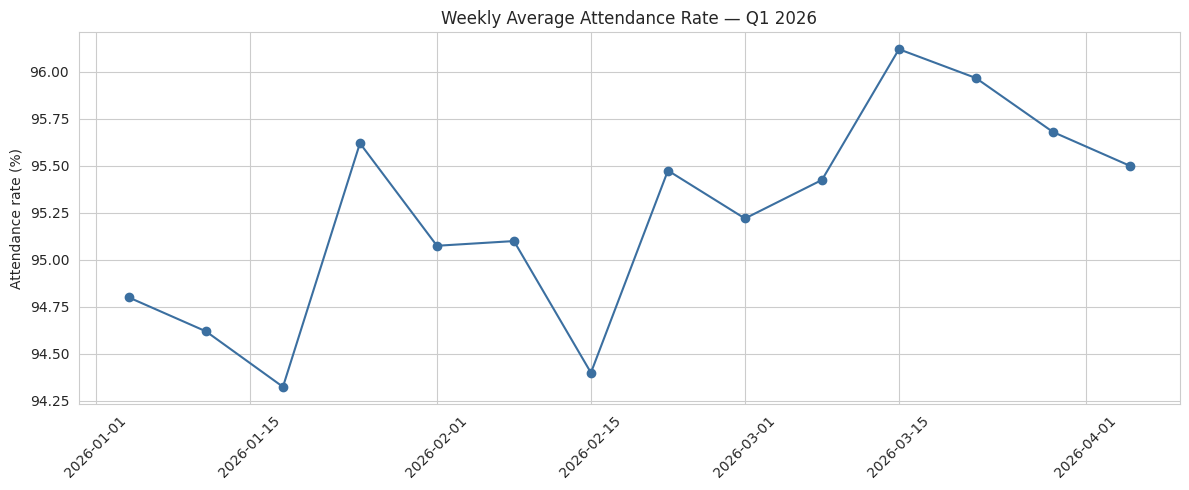

In [42]:
daily = df.groupby("attendance_date").agg(
    records=("employee_id", "count"),
    present=("attendance_status", lambda s: (s.isin(["Present", "Half Day"])).sum())
)
daily["attendance_rate_pct"] = (daily["present"] / daily["records"] * 100).round(1)
weekly = daily["attendance_rate_pct"].resample("W").mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(weekly.index, weekly.values, marker="o", color="#3b6fa0")
ax.set_title("Weekly Average Attendance Rate — Q1 2026")
ax.set_ylabel("Attendance rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

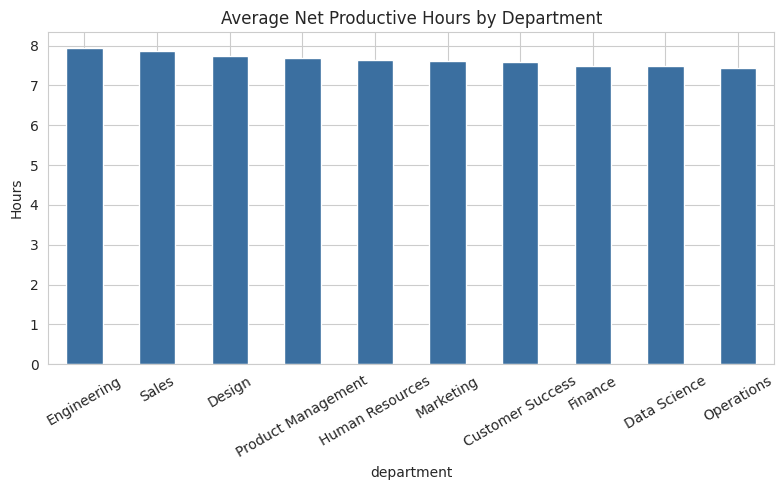

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))
df.groupby("department")["net_productive_hours"].mean().sort_values(ascending=False).plot.bar(ax=ax, color="#3b6fa0")
ax.set_title("Average Net Productive Hours by Department")
ax.set_ylabel("Hours")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

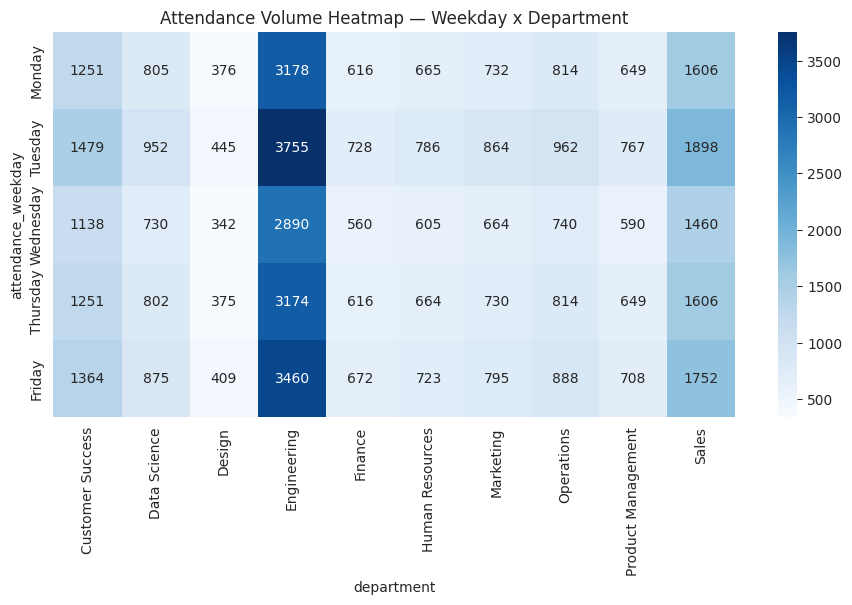

In [44]:
heat_data = df.pivot_table(index="attendance_weekday", columns="department",
                            values="employee_id", aggfunc="count")
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heat_data = heat_data.reindex([d for d in weekday_order if d in heat_data.index])

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(heat_data, cmap="Blues", annot=True, fmt=".0f", ax=ax)
ax.set_title("Attendance Volume Heatmap — Weekday x Department")
plt.show()

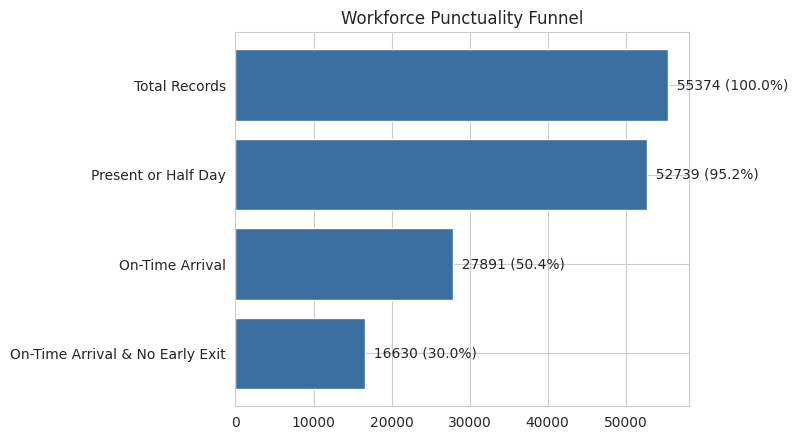

,stage,count,pct_of_total
0,Total Records,55374,100.0
1,Present or Half Day,52739,95.2
2,On-Time Arrival,27891,50.4
3,On-Time Arrival & No Early Exit,16630,30.0


In [45]:
funnel_stages = {
    "Total Records": len(df),
    "Present or Half Day": df["attendance_status"].isin(["Present", "Half Day"]).sum(),
    "On-Time Arrival": (df["late_arrival_mins"] == 0).sum(),
    "On-Time Arrival & No Early Exit": ((df["late_arrival_mins"] == 0) & (df["early_exit_mins"] == 0)).sum(),
}
funnel_df = pd.DataFrame({"stage": list(funnel_stages.keys()), "count": list(funnel_stages.values())})
funnel_df["pct_of_total"] = (funnel_df["count"] / funnel_df["count"].iloc[0] * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(funnel_df["stage"], funnel_df["count"], color="#3b6fa0")
for i, (c, p) in enumerate(zip(funnel_df["count"], funnel_df["pct_of_total"])):
    ax.text(c, i, f"  {c} ({p}%)", va="center")
ax.invert_yaxis()
ax.set_title("Workforce Punctuality Funnel")
plt.tight_layout()
plt.show()
funnel_df

## Conclusion

All 23 steps of the checklist have been applied end-to-end: the raw dataset was inspected (Steps
1–8) and found to be largely clean already, cleaned/typed and prepared into
`employee_attendance_bangalore_q1_2026_cleaned.csv` (Steps 9–17), statistically analyzed across
univariate, bivariate, multivariate, and hypothesis-testing lenses (Steps 18–21), and summarized
into dashboard-ready KPIs and charts (Steps 22–23).

**Key findings to carry into a dashboard:**
- Total hours worked and net productive hours are strongly positively correlated, as expected.
- Late-arrival minutes differ between Work-From-Home and Work-From-Office records (t-test).
- Net productive hours differ meaningfully across departments (ANOVA significant).
- Work-mode adoption (office vs. home vs. client site) is associated with department (Chi-square
  significant) — remote-work usage is uneven across teams.
